# Empirical Wavelet Transform: from 1D EWT to 2D EWT2D

This notebook walks through the **Empirical Wavelet Transform (EWT)** of Gilles (2013) and its **2D extension (EWT2D)** implemented in PySDKit.

## Why PySDKit?

Signal decomposition methods (EMD, EWT, VMD, ...) are powerful for non-stationary analysis, but historically lived in MATLAB. PySDKit brings them to Python with a unified, scikit-learn-style interface so they can serve as **feature engineering** tools for machine learning.

## References

> J. Gilles, *Empirical Wavelet Transform*, IEEE Trans. Signal Processing, 61(16):3999-4010, 2013.

> J. Gilles, G. Tran, S. Osher, *2D Empirical transforms. Wavelets, Ridgelets, and Curvelets revisited*, SIAM J. Imaging Sciences, 7(1):157-186, 2014.

Original MATLAB toolbox: [File Exchange 42141](https://www.mathworks.com/matlabcentral/fileexchange/42141-empirical-wavelet-transforms)

Python reference used here: `repo/EWT-Python`


## 1. Imports

In [2]:
import sys
from pathlib import Path

# Import the local pysdkit in this repository (not a separately installed copy)
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "examples":
    PROJECT_ROOT = PROJECT_ROOT.parent
# Also cover the case when the notebook cwd is elsewhere
CANDIDATES = [
    PROJECT_ROOT,
    Path(r"C:/Users/whenx/Desktop/PySDKit"),
]
for root in CANDIDATES:
    if (root / "pysdkit" / "__init__.py").exists():
        sys.path.insert(0, str(root))
        break

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import EWT, EWT2D, ewt, ewt2d
from pysdkit.data import test_emd, get_meshgrid_2D, test_univariate_image
import pysdkit

print("pysdkit from:", pysdkit.__file__)
print(EWT())
print(EWT2D())

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py
Empirical Wavelet Transform (EWT)
Empirical Wavelet Transform for 2D Images (EWT2D)


## 2. Core idea of 1D EWT (Gilles 2013)

Classical wavelets use a **prescribed** partition of the Fourier axis. EWT instead builds an **adaptive** Meyer filter bank from the signal itself:

1. Compute the magnitude spectrum $| \hat f(\omega) |$ on $[0,\pi]$.
2. Detect boundaries $\omega_n$ that separate meaningful spectral modes (local maxima, scale-space, ...).
3. Build a Meyer scaling function $\phi_1$ on $[0,\omega_1]$ and wavelets $\psi_n$ on $[\omega_n,\omega_{n+1}]$ with transition ratio
   $$
   \gamma < \min_n \frac{\omega_{n+1}-\omega_n}{\omega_{n+1}+\omega_n},
   $$
   so that $\{ \phi_1, \psi_n \}$ forms a **tight frame**:
   $$
   |\hat\phi_1(\omega)|^2 + \sum_n |\hat\psi_n(\omega)|^2 = 1.
   $$
4. Filter in the Fourier domain and return to time:
   $$
   f_n = \mathcal{F}^{-1}\!\big( \overline{\hat\psi_n}\,\hat f \big).
   $$

PySDKit exposes this as the class `EWT` with the familiar `fit_transform` interface.


## 3. 1D demo: adaptive spectrum segmentation

IMF shape (K, N): (3, 1000)
Detected boundaries (rad): [0.02199115 0.05654867]


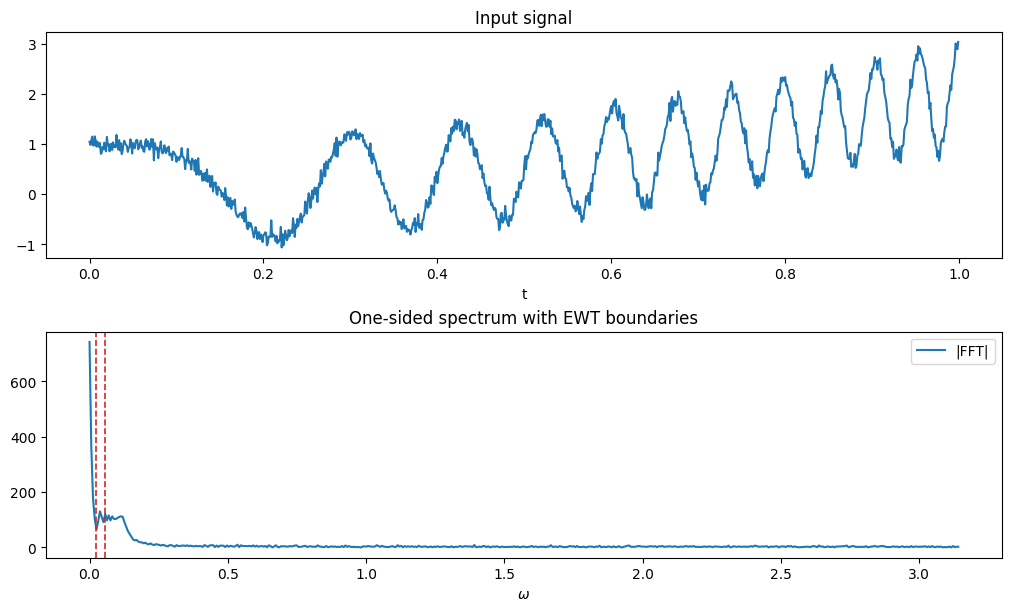

In [3]:
# Synthetic multi-tone signal from the library
t, signal = test_emd()

ewt_1d = EWT(K=3, detect="locmax", reg="average")
imfs, mfb, bounds = ewt_1d.fit_transform(signal, return_all=True)

print("IMF shape (K, N):", imfs.shape)
print("Detected boundaries (rad):", bounds)

# Spectrum + detected boundaries
spec = np.abs(np.fft.fft(signal))
half = spec[: len(spec) // 2]
freq = np.linspace(0, np.pi, len(half))

fig, axes = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)
axes[0].plot(t, signal, color="C0")
axes[0].set_title("Input signal")
axes[0].set_xlabel("t")

axes[1].plot(freq, half, color="C0", label="|FFT|")
for b in bounds:
    axes[1].axvline(b, color="C3", ls="--", lw=1.2)
axes[1].set_title("One-sided spectrum with EWT boundaries")
axes[1].set_xlabel(r"$\omega$")
axes[1].legend()
plt.show()

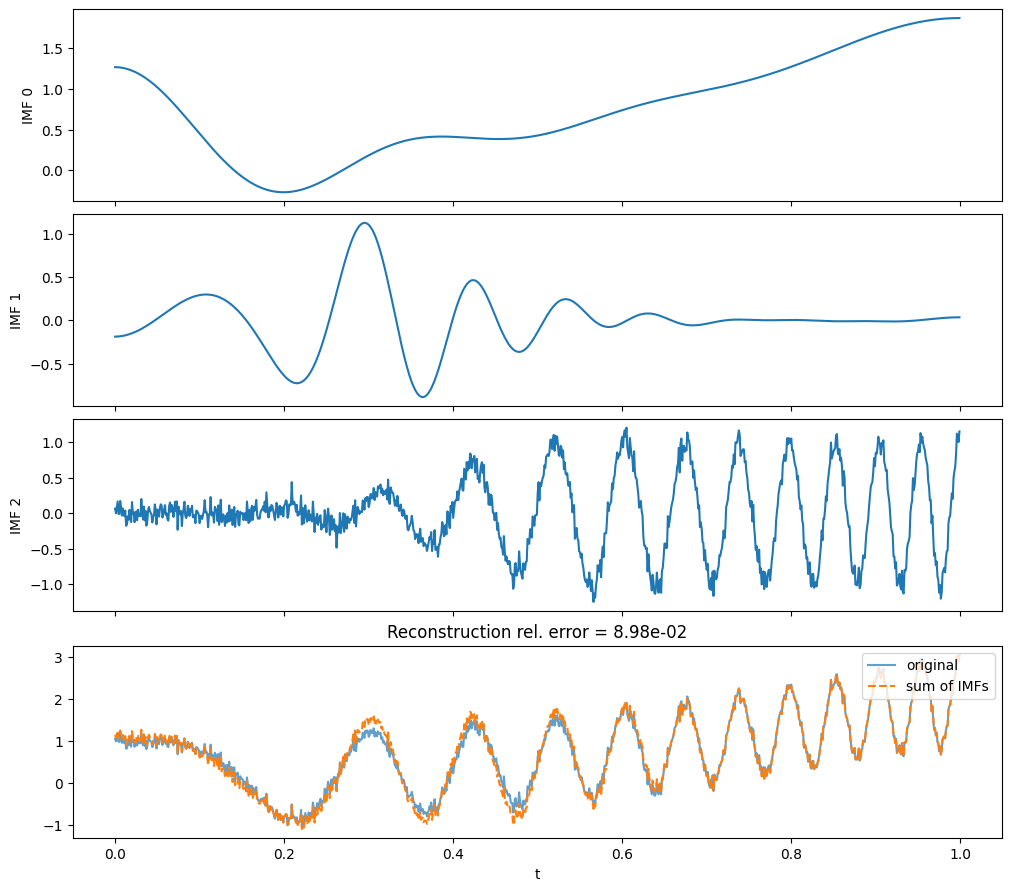

In [4]:
# Extracted modes
fig, axes = plt.subplots(
    imfs.shape[0] + 1,
    1,
    figsize=(10, 2.2 * (imfs.shape[0] + 1)),
    sharex=True,
    constrained_layout=True,
)
for k, ax in enumerate(axes[:-1]):
    ax.plot(t, imfs[k])
    ax.set_ylabel(f"IMF {k}")
recon = imfs.sum(axis=0)
axes[-1].plot(t, signal, label="original", alpha=0.7)
axes[-1].plot(t, recon, "--", label="sum of IMFs")
axes[-1].legend(loc="upper right")
axes[-1].set_xlabel("t")
err = np.linalg.norm(recon - signal) / np.linalg.norm(signal)
axes[-1].set_title(f"Reconstruction rel. error = {err:.2e}")
plt.show()

## 4. From 1D to 2D: Tensor EWT

For an image $f(x,y)$, the **Tensor EWT** (default in `EWT2D`) builds **independent** 1D filter banks along rows and columns:

1. Average the column-wise FFT magnitude to get a 1D spectrum $S_{\mathrm{col}}(\omega_y)$.
2. Detect boundaries and build Meyer filters $\Psi^{\mathrm{col}}_j$.
3. Do the same for rows $\rightarrow$ $\Psi^{\mathrm{row}}_i$.
4. Filter first along columns, then along rows.

Each mode lives on a **rectangle** in the 2D Fourier plane
$$
\Lambda_{i,j} = \Lambda^{\mathrm{row}}_i \times \Lambda^{\mathrm{col}}_j.
$$

Output shape is `(n_row * n_col, H, W)` with row-major ordering.


## 5. 2D demo: synthetic textured image

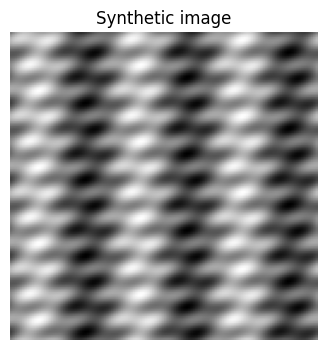

In [5]:
# Multi-orientation synthetic texture
size = 128
x, y = get_meshgrid_2D(low=0.0, high=1.0, sampling_rate=size)
image = (
    np.sin(2 * np.pi * 3 * x)
    + 0.6 * np.sin(2 * np.pi * 12 * y)
    + 0.4 * np.sin(2 * np.pi * 8 * (x + y))
)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(image, cmap="gray")
ax.set_title("Synthetic image")
ax.axis("off")
plt.show()

modes shape: (9, 128, 128)
n_row x n_col = 3 x 3
row bounds: [0.17180585 0.3436117 ]
col bounds: [0.17180585 0.46633016]


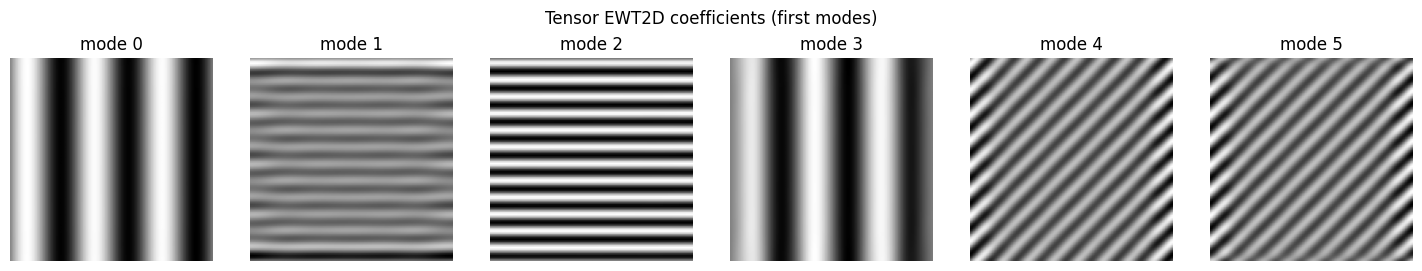

In [6]:
ewt2d_tensor = EWT2D(K=3, method="tensor", detect="locmax", reg="average")
modes, extras = ewt2d_tensor.fit_transform(image, return_all=True)

print("modes shape:", modes.shape)
print("n_row x n_col =", extras["n_row"], "x", extras["n_col"])
print("row bounds:", extras["bounds_row"])
print("col bounds:", extras["bounds_col"])

n_show = min(6, modes.shape[0])
fig, axes = plt.subplots(
    1, n_show, figsize=(2.4 * n_show, 2.6), constrained_layout=True
)
for k, ax in enumerate(axes):
    ax.imshow(modes[k], cmap="gray")
    ax.set_title(f"mode {k}")
    ax.axis("off")
plt.suptitle("Tensor EWT2D coefficients (first modes)")
plt.show()

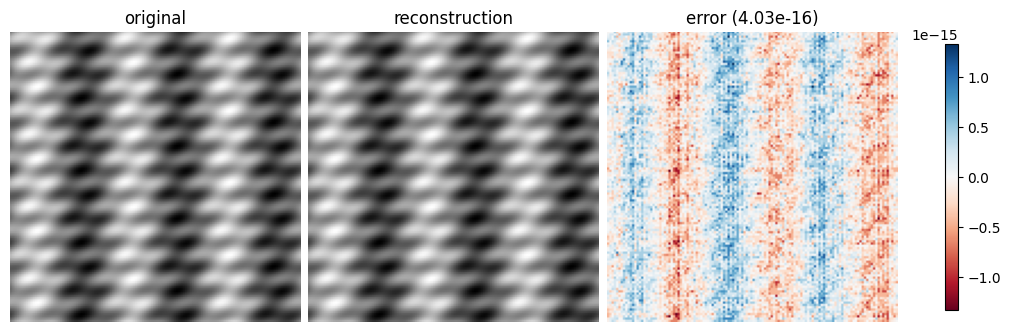

In [7]:
# Tight-frame reconstruction
recon = ewt2d_tensor.inverse_transform(modes, extras=extras)
rel_err = np.linalg.norm(recon - image) / np.linalg.norm(image)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), constrained_layout=True)
axes[0].imshow(image, cmap="gray")
axes[0].set_title("original")
axes[0].axis("off")
axes[1].imshow(recon, cmap="gray")
axes[1].set_title("reconstruction")
axes[1].axis("off")
im = axes[2].imshow(recon - image, cmap="RdBu")
axes[2].set_title(f"error ({rel_err:.2e})")
axes[2].axis("off")
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.show()

## 6. Visualising Tensor Fourier supports

Because Tensor EWT is separable, the detected row / column boundaries tile the 2D spectrum into rectangles. Below we overlay them on $\log|\mathrm{FFT2}(f)|$.


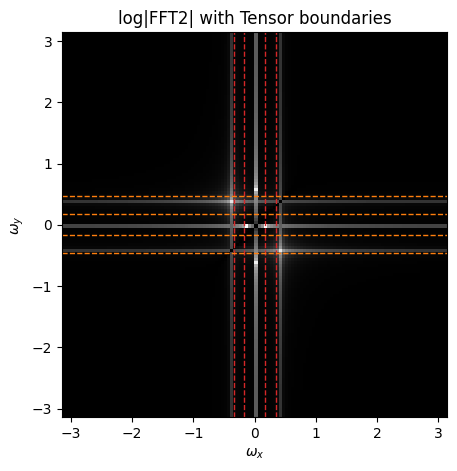

In [8]:
H, W = image.shape
F = np.fft.fftshift(np.fft.fft2(image))
mag = np.log1p(np.abs(F))

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(mag, cmap="gray", extent=[-np.pi, np.pi, -np.pi, np.pi])
for b in extras["bounds_row"]:
    ax.axvline(b, color="C3", ls="--", lw=1)
    ax.axvline(-b, color="C3", ls="--", lw=1)
for b in extras["bounds_col"]:
    ax.axhline(b, color="C1", ls="--", lw=1)
    ax.axhline(-b, color="C1", ls="--", lw=1)
ax.set_title("log|FFT2| with Tensor boundaries")
ax.set_xlabel(r"$\omega_x$")
ax.set_ylabel(r"$\omega_y$")
plt.show()

## 7. Littlewood-Paley (LP) EWT2D

The LP method partitions the **radial** frequency axis into annuli:

1. Form a radial spectrum (via the pseudo-polar FFT, as in Gilles / EWT-Python).
2. Detect scale boundaries $\rho_n$.
3. Build a low-pass disk $\hat\phi$ and annular wavelets $\hat\psi_n$.
4. Filter with 2D FFT / IFFT.

Supports are **rotation-invariant rings** rather than rectangles — useful when texture energy is isotropic.


LP modes shape: (3, 128, 128)
scale bounds: [1.34990309 2.85934019]
reconstruction rel. error: 3.98e-16


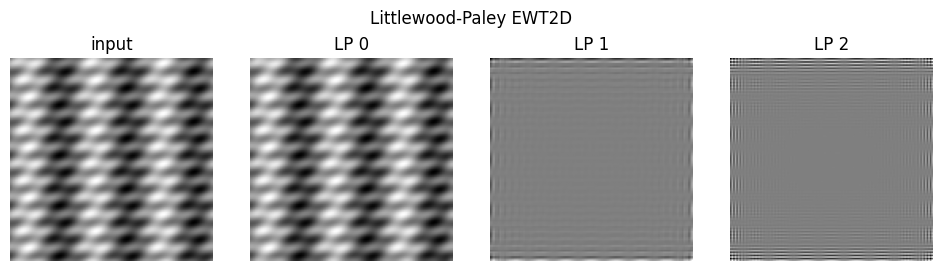

In [9]:
ewt2d_lp = EWT2D(K=3, method="lp", detect="locmax", reg="average")
modes_lp, extras_lp = ewt2d_lp.fit_transform(image, return_all=True)
recon_lp = ewt2d_lp.inverse_transform(modes_lp, extras=extras_lp)
rel_err_lp = np.linalg.norm(recon_lp - image) / np.linalg.norm(image)

print("LP modes shape:", modes_lp.shape)
print("scale bounds:", extras_lp["bounds_scales"])
print("reconstruction rel. error:", f"{rel_err_lp:.2e}")

n_show = modes_lp.shape[0]
fig, axes = plt.subplots(
    1, n_show + 1, figsize=(2.4 * (n_show + 1), 2.6), constrained_layout=True
)
axes[0].imshow(image, cmap="gray")
axes[0].set_title("input")
axes[0].axis("off")
for k in range(n_show):
    axes[k + 1].imshow(modes_lp[k], cmap="gray")
    axes[k + 1].set_title(f"LP {k}")
    axes[k + 1].axis("off")
plt.suptitle("Littlewood-Paley EWT2D")
plt.show()

## 8. Side-by-side: Tensor vs LP on a library image

`test_univariate_image` provides several synthetic textures used across PySDKit's 2D algorithms.


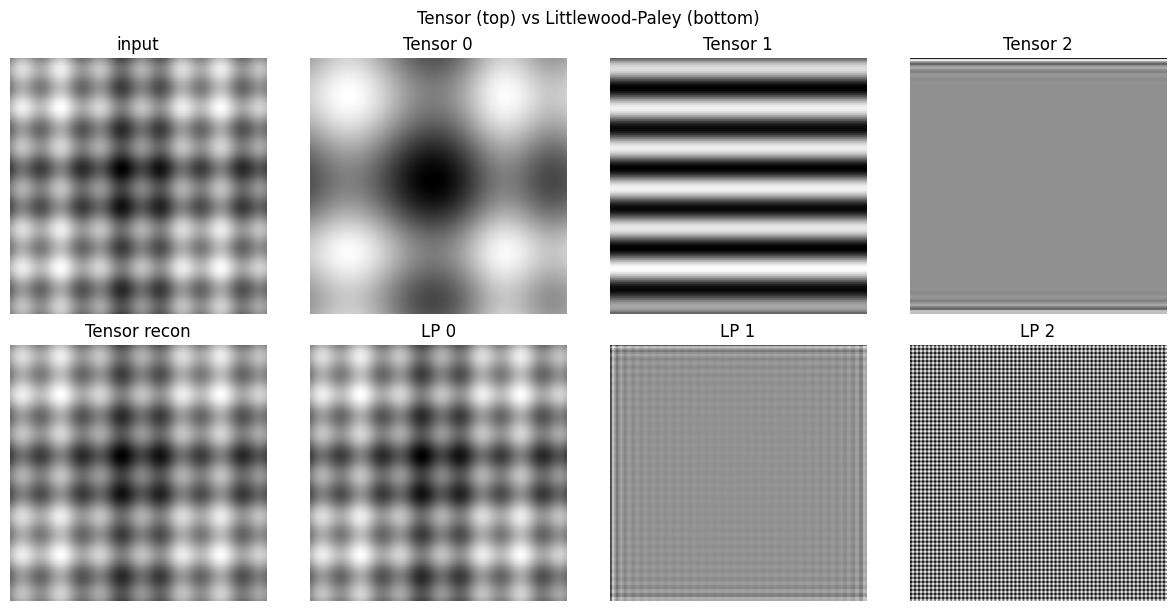

In [10]:
img = test_univariate_image(case=1, sampling_rate=128)

modes_t, ex_t = EWT2D(K=3, method="tensor").fit_transform(img, return_all=True)
modes_l, ex_l = EWT2D(K=3, method="lp").fit_transform(img, return_all=True)

fig, axes = plt.subplots(2, 4, figsize=(12, 6), constrained_layout=True)
axes[0, 0].imshow(img, cmap="gray")
axes[0, 0].set_title("input")
for k in range(3):
    axes[0, k + 1].imshow(modes_t[k], cmap="gray")
    axes[0, k + 1].set_title(f"Tensor {k}")
    axes[1, k + 1].imshow(modes_l[min(k, modes_l.shape[0] - 1)], cmap="gray")
    axes[1, k + 1].set_title(f"LP {k}")
axes[1, 0].imshow(
    EWT2D(K=3, method="tensor").inverse_transform(modes_t, ex_t), cmap="gray"
)
axes[1, 0].set_title("Tensor recon")
for ax in axes.ravel():
    ax.axis("off")
plt.suptitle("Tensor (top) vs Littlewood-Paley (bottom)")
plt.show()

## 9. API summary

```python
from pysdkit import EWT, EWT2D

# 1D
ewt = EWT(K=5, detect="locmax", reg="average")
imfs = ewt.fit_transform(signal)                  # (K, N)
imfs, mfb, bounds = ewt.fit_transform(signal, return_all=True)

# 2D Tensor (default)
ewt2d = EWT2D(K=3, method="tensor")
modes = ewt2d.fit_transform(image)                # (n_modes, H, W)
modes, extras = ewt2d.fit_transform(image, return_all=True)
recon = ewt2d.inverse_transform(modes)            # uses cached filters

# 2D Littlewood-Paley
ewt2d_lp = EWT2D(K=3, method="lp")
modes_lp = ewt2d_lp.fit_transform(image)
```

Functional shortcuts: `ewt(...)`, `ewt2d(...)`.


## 10. Takeaways

| Aspect | 1D EWT | Tensor EWT2D | LP EWT2D |
|--------|--------|--------------|----------|
| Spectrum used | $\| \hat f(\omega) \|$ | row & column averages | radial (pseudo-polar) |
| Support shape | intervals on $[0,\pi]$ | rectangles | annuli |
| Output | `(K, N)` | `(n_row·n_col, H, W)` | `(n_scales, H, W)` |
| Reconstruction | sum of IMFs ≈ signal | `inverse_transform` (tight frame) | same |

EWT adapts the wavelet supports to the data — the same principle that motivates EMD, but with an explicit Fourier construction and a proven tight-frame filter bank. EWT2D lifts that construction to images, either separably (Tensor) or radially (LP).
